In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor

In [2]:
# Load dataset
data = pd.read_csv("insuranceWithFeatures.csv")

# Separate features and target
X = data.drop(['charges','sex','smoker','region','log_charges'], axis=1)
y = data['charges']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(exclude=['object']).columns.tolist()

In [3]:
# Define boosting model
gbr = GradientBoostingRegressor(
    n_estimators=125,
    learning_rate=0.05,
    max_depth=10,
    random_state=42)

gbr.fit(X_train, y_train)

y_pred=gbr.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Performance:")
print("------------------")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R² Score: {r2:.4f}")

Model Performance:
------------------
RMSE: 5201.20
MAE: 2551.39
R² Score: 0.8257


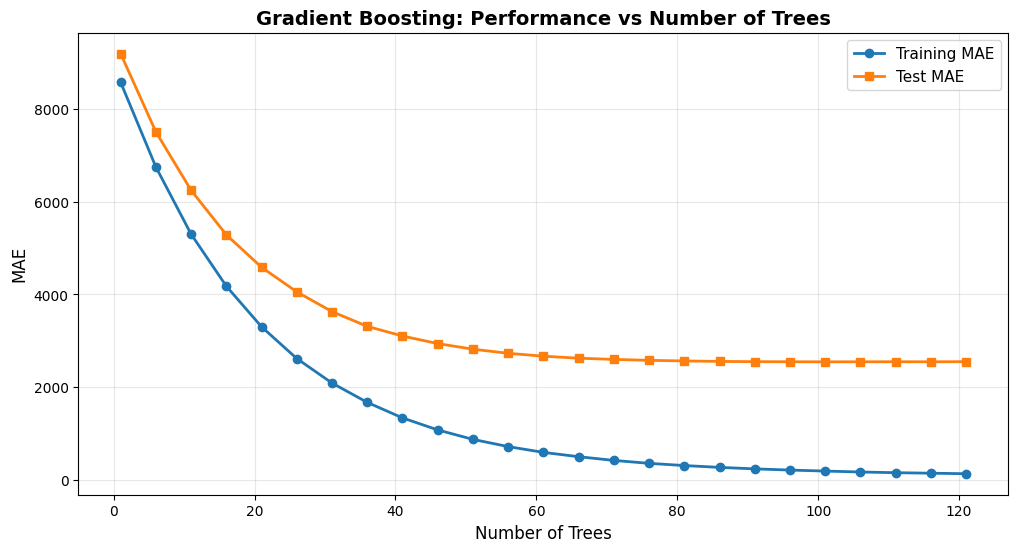


 Observations:
1. Both training and test error decrease steadily
2. Training error keeps going down (eventual overfitting risk)
3. Test error plateaus around 65-120 trees

 Boosting gradually improves predictions by fixing errors!


In [4]:
train_scores = []
test_scores = []
n_estimators_list = range(1, 126, 5)

for n_est in n_estimators_list:
    gb_temp = GradientBoostingRegressor(
        n_estimators=n_est,
        max_depth=10,
        learning_rate=0.05,
        random_state=42
    )
    gb_temp.fit(X_train, y_train)

    train_pred = gb_temp.predict(X_train)
    test_pred = gb_temp.predict(X_test)

    train_scores.append(mean_absolute_error(y_train, train_pred))
    test_scores.append(mean_absolute_error(y_test, test_pred))

plt.figure(figsize=(12, 6))
plt.plot(n_estimators_list, train_scores, 'o-', linewidth=2, markersize=6, label='Training MAE')
plt.plot(n_estimators_list, test_scores, 's-', linewidth=2, markersize=6, label='Test MAE')
plt.xlabel('Number of Trees', fontsize=12)
plt.ylabel('MAE', fontsize=12)
plt.title('Gradient Boosting: Performance vs Number of Trees', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

print("\n Observations:")
print("1. Both training and test error decrease steadily")
print("2. Training error keeps going down (eventual overfitting risk)")
print("3. Test error plateaus around 65-120 trees")
print("\n Boosting gradually improves predictions by fixing errors!")

In [5]:
# Hyperparameter grid
param_grid = {
    'n_estimators': [25, 50, 75, 100, 200, 300],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [2, 3, 4, 5, 10],
    'min_samples_split': [2, 5, 6, 7],
    'min_samples_leaf': [1, 2, 3]
}

# Cross-validation strategy
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Grid search with cross-validation
grid_search = GridSearchCV(
    estimator=gbr,
    param_grid=param_grid,
    cv=kfold,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

# Fit model
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 1440 candidates, totalling 7200 fits


GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=GradientBoostingRegressor(learning_rate=0.05,
                                                 max_depth=10, n_estimators=125,
                                                 random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.03, 0.05, 0.1],
                         'max_depth': [2, 3, 4, 5, 10],
                         'min_samples_leaf': [1, 2, 3],
                         'min_samples_split': [2, 5, 6, 7],
                         'n_estimators': [25, 50, 75, 100, 200, 300]},
             scoring='r2', verbose=1)

In [6]:
# Best model
best_model = grid_search.best_estimator_

# Predictions
y_pred = best_model.predict(X_test)

# Performance metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Best Hyperparameters:", grid_search.best_params_)
print("\nPerformance on Test Set:")
print(f"R^2 Score: {r2:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
# Display results
results_df = pd.DataFrame(grid_search.cv_results_)
best_params = grid_search.best_params_

print("Best Hyperparameters:")
print(best_params)
print(f"\nCross-Validated RMSE: {rmse:.3f}")
print(f"R^2 Score: {r2:.3f}")

Best Hyperparameters: {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 3, 'min_samples_split': 7, 'n_estimators': 100}

Performance on Test Set:
R^2 Score: 0.88
RMSE: 4315.52
MAE: 2492.18
Best Hyperparameters:
{'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 3, 'min_samples_split': 7, 'n_estimators': 100}

Cross-Validated RMSE: 4315.519
R^2 Score: 0.880


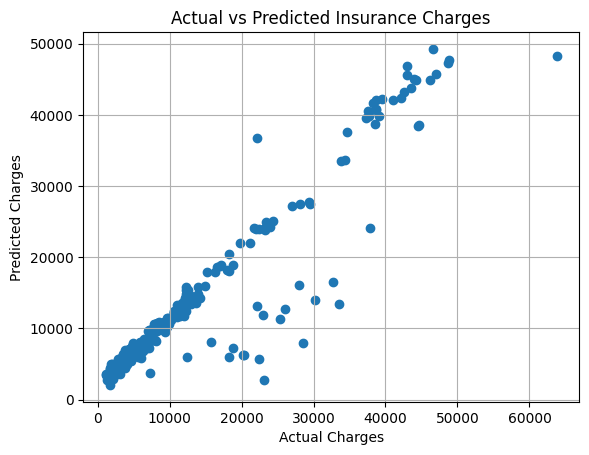

In [7]:
#print(results_df.describe())
# Plot Actual vs Predicted
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Charges")
plt.grid()
plt.show()

In [8]:
# Using XGBoost
xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=42
)

param_grid_xgb = {
    'n_estimators': [75, 80, 85, 90, 100, 200, 300],
    'learning_rate': [0.03, 0.02, 0.05, 0.1],
    'max_depth': [2, 3, 4],
    'subsample': [0.6, 0.75, 0.8, 0.85, 0.9, 1.0],
    'colsample_bytree': [0.75, 0.8, 0.85, 0.9, 1.0]
}

grid_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid_xgb,
    cv=kfold,
    scoring='r2',
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

best_xgb = grid_xgb.best_estimator_

print("\nBest Hyperparameters for XGBoost:")
print(grid_xgb.best_params_)


Best Hyperparameters for XGBoost:
{'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 90, 'subsample': 0.8}


In [9]:
y_pred_xgb = best_xgb.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("\nXGBoost Performance:")
print(f"RMSE: {rmse_xgb:.2f}")
print(f"MAE: {mae_xgb:.2f}")
print(f"r2: {r2_xgb:.3f}")



XGBoost Performance:
RMSE: 4277.61
MAE: 2511.65
r2: 0.882
